/home/liue/.local/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


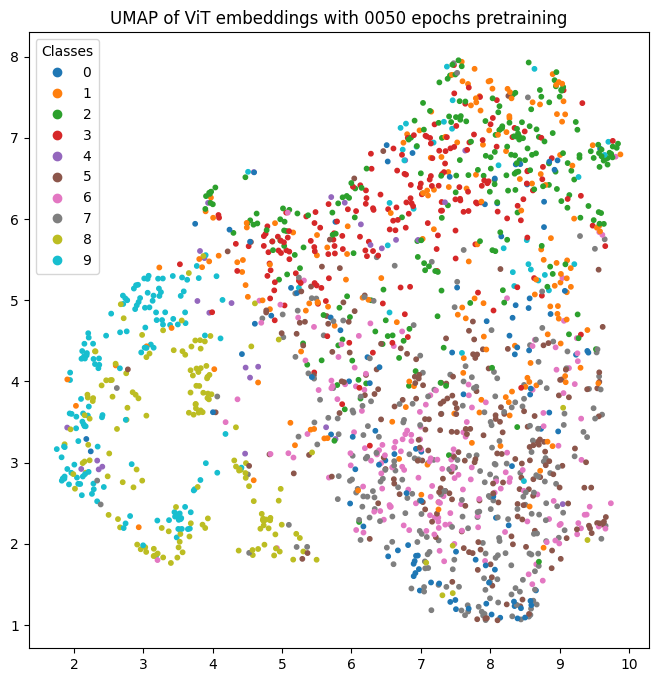

/home/liue/.local/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


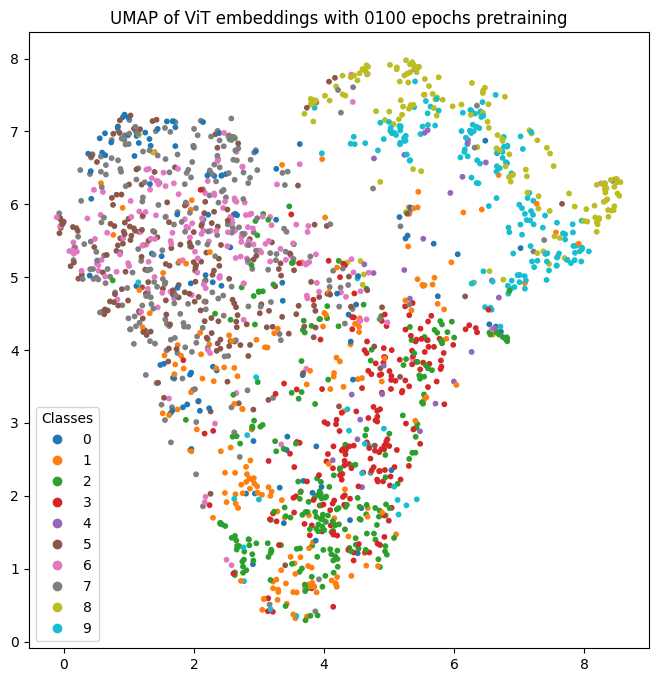

/home/liue/.local/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


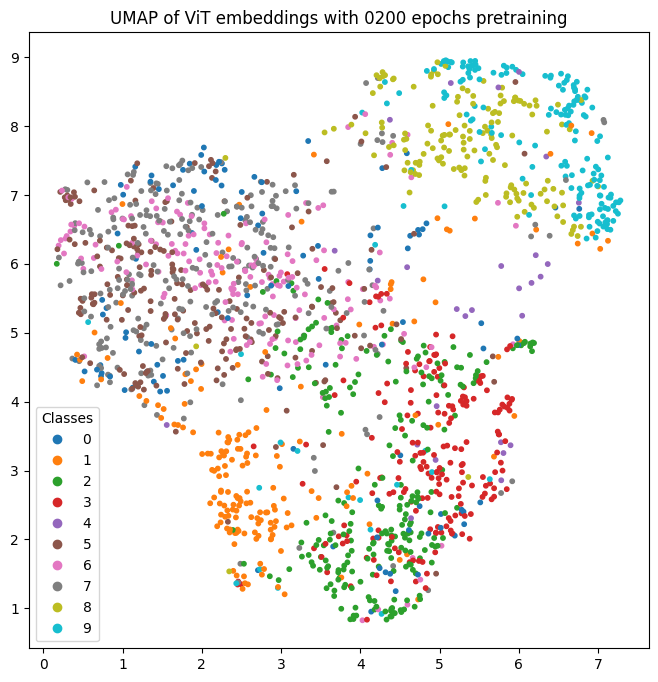

/home/liue/.local/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


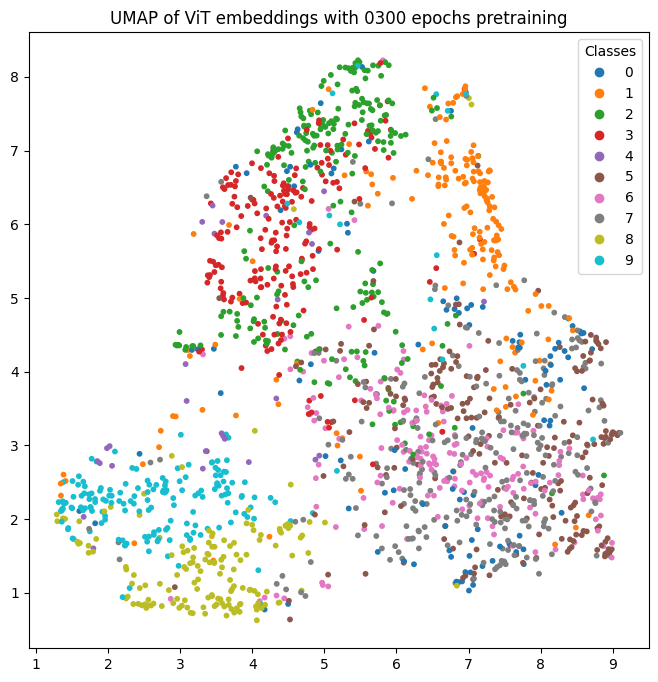

In [1]:
import os
os.chdir("..")

from scripts.lp_script import construct_backbone
from data.data import get_ssl_test_dataloader
import torch
import yaml
    
import umap
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

with open("./configs/config.yaml", "r") as f:
    config = yaml.safe_load(f)

for i in ["0050", "0100", "0200", "0300"]:
    backbone = construct_backbone(
        arch=config["arch"],
        ckpt_path= f"./checkpoints_{config['arch']}_{config['ssl_batch_size']}_{config['ssl_lr']}_{config['ssl_wd']}/checkpoint_{i}.pth.tar",
        moco_t=config["moco_t"],
        moco_dim=config["moco_dim"],
        moco_mlp_dim=config["moco_mlp_dim"],
        device=device,
    )

    test_loader = get_ssl_test_dataloader(batch_size=config["lp_batch_size"], workers=config["workers"])
    features, labels = [], []
    with torch.no_grad():
        for imgs, lbls in test_loader:
            emb = backbone(imgs.to(device))
            features.append(emb.cpu())
            labels.append(lbls)
            
    features = torch.cat(features).numpy()
    labels = torch.cat(labels).numpy()


    reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, metric="cosine", random_state=2952)
    embedding_2d = reducer.fit_transform(features)

    plt.figure(figsize=(8,8))
    scatter = plt.scatter(embedding_2d[:,0], embedding_2d[:,1], c=labels, cmap="tab10", s=10)
    plt.legend(*scatter.legend_elements(), title="Classes")
    plt.title(f"UMAP of ViT embeddings with {i} epochs pretraining")
    plt.show()